#  Step 1: Import Libraries

In [1]:

import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

#  Step 2: Load the Dataset

In [2]:

(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Step 3: Preprocess the Data

In [3]:
# Reshape to (samples, height, width, channels)
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255
x_test  = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255

In [4]:
# One-hot encode labels (0–9)
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test, 10)

In [ ]:
#Optional: Show a few images
for i in range(5):
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {y_train[i].argmax()}")
    plt.show()

# Step 4: Build the CNN Model

In [5]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),  # Edge detection
    MaxPooling2D(pool_size=(2, 2)),  # Downsample

    Conv2D(64, (3, 3), activation='relu'),  # Deeper patterns
    MaxPooling2D(pool_size=(2, 2)),

    Flatten(),  # Flatten into 1D
    Dense(128, activation='relu'),  # Fully connected
    Dropout(0.3),  # Regularization to prevent overfitting
    Dense(10, activation='softmax')  # Output layer: 10 classes
])

C:\Users\maahi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Step 5: Compile the Model

In [6]:
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Step 6: Train the Model

In [7]:
model.fit(x_train, y_train,
          validation_split=0.1,
          epochs=5,
          batch_size=64)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 35s 37ms/step - accuracy: 0.8535 - loss: 0.4623 - val_accuracy: 0.9858 - val_loss: 0.0524
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 42s 38ms/step - accuracy: 0.9761 - loss: 0.0746 - val_accuracy: 0.9887 - val_loss: 0.0403
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 38ms/step - accuracy: 0.9841 - loss: 0.0513 - val_accuracy: 0.9883 - val_loss: 0.0370
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 37ms/step - accuracy: 0.9878 - loss: 0.0377 - val_accuracy: 0.9898 - val_loss: 0.0376
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 41s 37ms/step - accuracy: 0.9897 - loss: 0.0314 - val_accuracy: 0.9908 - val_loss: 0.0359


# Step 7: Evaluate on Test Data

In [8]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"✅ Test Accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9854 - loss: 0.0400
✅ Test Accuracy: 0.9890


# Step 8: Make Predictions

In [9]:
import numpy as np
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step


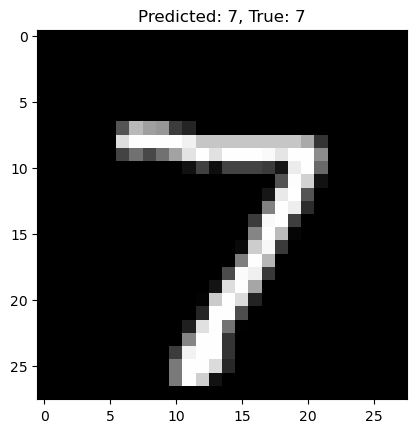

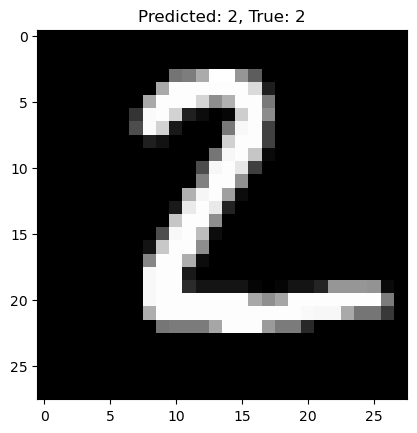

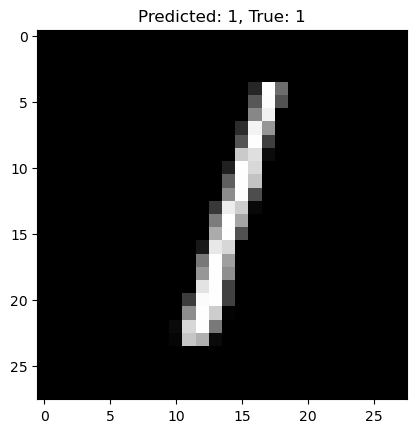

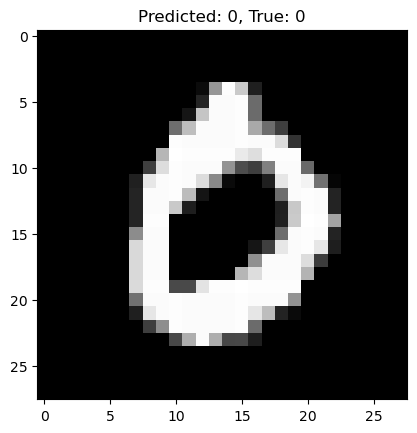

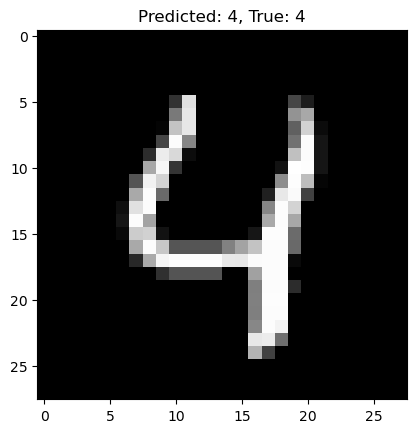

In [10]:
# Show predictions on first 5 test images
for i in range(5):
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Predicted: {np.argmax(predictions[i])}, True: {np.argmax(y_test[i])}")
    plt.show()